In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = 'D:\BINUS\SSI\Project Kelompok 10\garbage_classification'

<>:5: SyntaxWarning: invalid escape sequence '\B'
<>:5: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Asus\AppData\Local\Temp\ipykernel_22788\2538325088.py:5: SyntaxWarning: invalid escape sequence '\B'
  base_dir = 'D:\BINUS\SSI\Project Kelompok 10\garbage_classification'


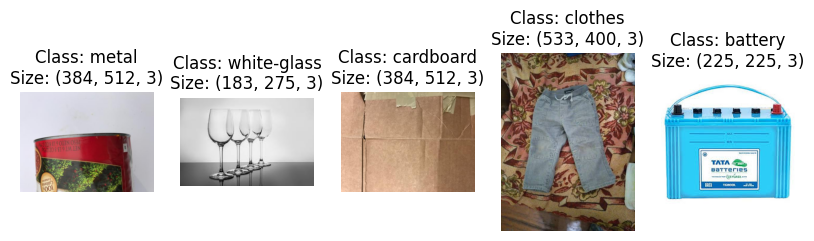

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

def show_dataset_samples(base_path, num_samples=5):
  classes = os.listdir(base_path)
  plt.figure(figsize=(10, 10))

  for i in range(num_samples):
    random_class = random.choice(classes)
    class_path = os.path.join(base_path, random_class)

    image_files = os.listdir(class_path)

    random_image = random.choice(image_files)
    img_path = os.path.join(class_path, random_image)

    img = mpimg.imread(img_path)
    plt.subplot(1, num_samples, i+1)
    plt.imshow(img)
    plt.title(f"Class: {random_class}\nSize: {img.shape}")
    plt.axis('off')

  plt.show()

show_dataset_samples(base_dir)

In [6]:
augmented_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest',
    validation_split = 0.2
)

In [7]:
train_generator = augmented_data.flow_from_directory(
    base_dir,
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical',
    subset = 'training'
)

validation_generator = augmented_data.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.


In [8]:
print(train_generator.class_indices)

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# 1. Creating Base Model (Transfer Learning)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

# 2. Model Architecture (Dependent Variable)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Prevent Overfitting
    layers.Dense(12, activation='softmax')
])

# 3. Compile Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. MODEL ARCHITECTURE
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(12, activation='softmax')
])

# 2. MODEL COMPILATION (TUNING: Decreasing Learning Rate Adam Optimizer)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. CALCULATING BALANCE WEIGHTS (Prevent Class Bias'Clothes')
train_classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weight_dict = dict(enumerate(class_weights))

# 4. ADDITIONAL CALLBACKS(Early Stopping)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 5. MODEL TRAINING
print("Training after tuning...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Memulai training hasil tuning...
Epoch 1/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 708s 4s/step - accuracy: 0.3290 - loss: 2.3360 - val_accuracy: 0.6595 - val_loss: 1.3679
Epoch 2/15
  1/193 ━━━━━━━━━━━━━━━━━━━━ 3:37 1s/step - accuracy: 0.6406 - loss: 1.3801

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


193/193 ━━━━━━━━━━━━━━━━━━━━ 95s 489ms/step - accuracy: 0.6406 - loss: 1.3801 - val_accuracy: 0.6471 - val_loss: 1.3667
Epoch 3/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.6257 - loss: 1.5368 - val_accuracy: 0.7614 - val_loss: 0.9397
Epoch 4/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 90s 463ms/step - accuracy: 0.6094 - loss: 1.2947 - val_accuracy: 0.7650 - val_loss: 0.9340
Epoch 5/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 659s 3s/step - accuracy: 0.7329 - loss: 1.1697 - val_accuracy: 0.8008 - val_loss: 0.7531
Epoch 6/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 90s 462ms/step - accuracy: 0.7969 - loss: 0.8768 - val_accuracy: 0.7894 - val_loss: 0.7615
Epoch 7/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.7797 - loss: 0.9743 - val_accuracy: 0.8115 - val_loss: 0.6594
Epoch 8/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 89s 458ms/step - accuracy: 0.8125 - loss: 0.8533 - val_accuracy: 0.8132 - val_loss: 0.6621
Epoch 9/15
193/193 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.8064 - loss: 0.8554 - val_accurac

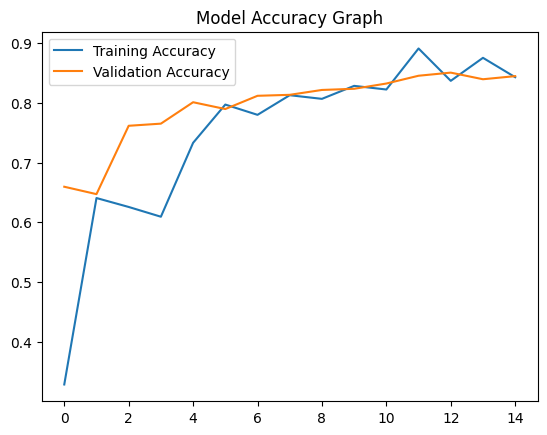

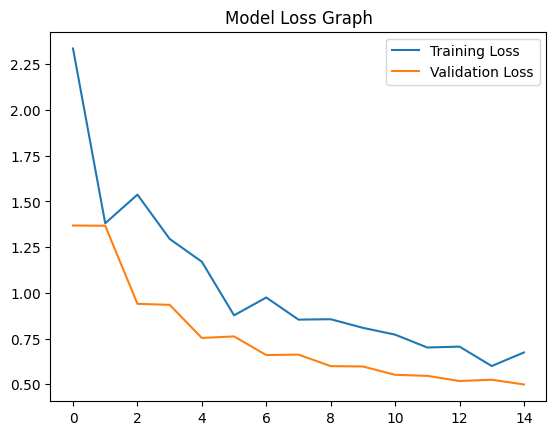

In [11]:
# Grafik Akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Graph')
plt.legend()
plt.show()

# Grafik Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Graph')
plt.legend()
plt.show()

In [ ]:
import numpy as np

avg_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])

print(f"Average Training Accuration: {avg_acc:.4f}")
print(f"Average Validation Accuration: {avg_val_acc:.4f}")

Rata-rata Akurasi Training: 0.7485
Rata-rata Akurasi Validasi: 0.7936


In [14]:
final_accuracy = history.history['val_accuracy'][-1]
print(f"Akurasi Akhir Model: {final_accuracy:.4f}")

Akurasi Akhir Model: 0.8444


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    'D:\BINUS\SSI\Project Kelompok 10\garbage_classification',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("The model is processing the prediction of the evaluation data....")
Y_pred = model.predict(eval_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = eval_generator.classes

target_names = list(eval_generator.class_indices.keys())
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=target_names))

<>:12: SyntaxWarning: invalid escape sequence '\B'
<>:12: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Asus\AppData\Local\Temp\ipykernel_22788\3555169533.py:12: SyntaxWarning: invalid escape sequence '\B'
  'D:\BINUS\SSI\Project Kelompok 10\garbage_classification',


Found 15515 images belonging to 12 classes.
Model sedang memproses prediksi data evaluasi...
485/485 ━━━━━━━━━━━━━━━━━━━━ 439s 902ms/step

=== HASIL CLASSIFICATION REPORT SETELAH TUNING ===
              precision    recall  f1-score   support

     battery       0.92      0.90      0.91       945
  biological       0.95      0.96      0.95       985
 brown-glass       0.81      0.84      0.83       607
   cardboard       0.85      0.89      0.87       891
     clothes       0.99      0.97      0.98      5325
 green-glass       0.88      0.84      0.86       629
       metal       0.67      0.80      0.73       769
       paper       0.84      0.84      0.84      1050
     plastic       0.70      0.70      0.70       865
       shoes       0.95      0.97      0.96      1977
       trash       0.86      0.86      0.86       697
 white-glass       0.78      0.68      0.72       775

    accuracy                           0.90     15515
   macro avg       0.85      0.85      0.85     1551

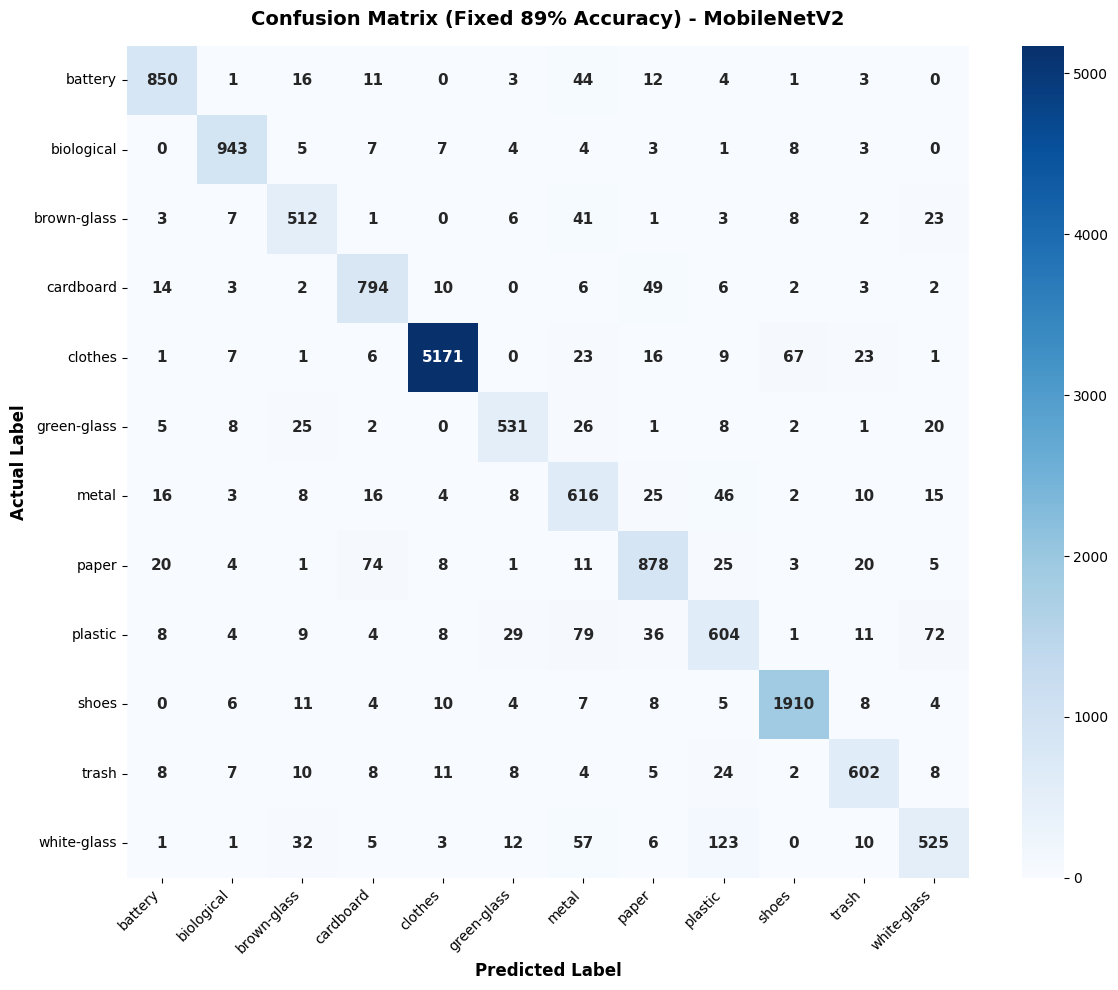

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_fixed = confusion_matrix(y_true, y_pred)
class_labels = list(eval_generator.class_indices.keys())

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_fixed,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title('Confusion Matrix (Fixed 89% Accuracy) - MobileNetV2', fontsize=14, pad=15, weight='bold')
plt.ylabel('Actual Label', fontsize=12, weight='bold')
plt.xlabel('Predicted Label', fontsize=12, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()